<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/MachineLearning/SistemasInteligentes/SistemasInteligentes_ClassificadorCavalos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# dataset de cavalos kaggle
import kagglehub
# executa função do dataset e python baixa arquivos e salva cominho da pasta
path = kagglehub.dataset_download("olgabelitskaya/horse-breeds")
# caminho onde os arquivos foram salvos
print("Pasta que as imagens estão guardadas:", path)

In [ ]:
# dataset de pessoas kaggle
# usando pandas para selecionar alearotiamente uma quantidade de imagens do dataset
import kagglehub

path = kagglehub.dataset_download("ahmadahmadzada/images2000")
print("Pasta que as imagens estão guardadas:", path)


In [ ]:
import os
import shutil
import random
from google.colab import drive

drive.mount('/content/drive')

# Definição de caminhos
diretorio_dataset_cavalos = "/root/.cache/kagglehub/datasets/olgabelitskaya/horse-breeds/versions/27"
diretorio_dataset_nao_cavalos = "/root/.cache/kagglehub/datasets/ahmadahmadzada/images2000/versions/1"
diretorio_destinoDrive = "/content/drive/MyDrive/Trabalho_SistemasInteligentes"

# Pasta temporária para organizar antes de zipar
pasta_temp = "/content/temp_dataset"
os.makedirs(pasta_temp, exist_ok=True)

# Função para selecionar e preparar dados
def preparar_dados():
    caminhos_cavalos = [os.path.join(raiz, arq) for raiz, _, arqs in os.walk(diretorio_dataset_cavalos) for arq in arqs if arq.lower().endswith(('.png', '.jpg', '.jpeg'))]
    caminhos_nao_cavalos_full = [os.path.join(raiz, arq) for raiz, _, arqs in os.walk(diretorio_dataset_nao_cavalos) for arq in arqs if arq.lower().endswith(('.png', '.jpg', '.jpeg'))]

    qtd_ideal = min(len(cavalos_sel := caminhos_cavalos[:len(caminhos_cavalos)]), len(caminhos_nao_cavalos_full))
    caminhos_nao_cavalos_sel = random.sample(caminhos_nao_cavalos_full, qtd_ideal)

    return caminhos_cavalos[:qtd_ideal], caminhos_nao_cavalos_sel

cavalos, nao_cavalos = preparar_dados()

# Organizar em pastas temporárias e renomear
def organizar(lista, pasta_nome):
    destino = os.path.join(pasta_temp, pasta_nome)
    os.makedirs(destino, exist_ok=True)
    for i, origem in enumerate(lista, 1):
        ext = os.path.splitext(origem)[1]
        shutil.copy2(origem, os.path.join(destino, f"{i}{ext}"))
    return destino

dir_cav = organizar(cavalos, "cavalos")
dir_nao = organizar(nao_cavalos, "nao_cavalos")

# Compactar e mover para o Drive
print("Compactando e enviando para o Drive...")
shutil.make_archive(os.path.join(diretorio_destinoDrive, "cavalos"), 'zip', dir_cav)
shutil.make_archive(os.path.join(diretorio_destinoDrive, "nao_cavalos"), 'zip', dir_nao)

# Limpeza
shutil.rmtree(pasta_temp)

print("Processo finalizado com sucesso. Arquivos .zip criados no seu Drive.")

# Inicio de execução ao ter o dataset no drive:

In [1]:
import zipfile
import os
import shutil
from google.colab import drive

# Montar Drive
drive.mount('/content/drive', force_remount=True)

# Configurações
caminho_drive = '/content/drive/MyDrive/Trabalho_SistemasInteligentes'
caminho_local = '/content/'

# Dicionário mapeando o nome do arquivo ZIP para a pasta de destino desejada
processos = {
    'cavalos.zip': 'cavalos',
    'nao_cavalos.zip': 'nao_cavalos'
}

# Execução
for nome_zip, pasta_destino in processos.items():
    caminho_origem_zip = os.path.join(caminho_drive, nome_zip)
    caminho_pasta_final = os.path.join(caminho_local, pasta_destino)

    # Cria a pasta de destino (garante que exista)
    os.makedirs(caminho_pasta_final, exist_ok=True)

    if os.path.exists(caminho_origem_zip):
        print(f"Extraindo {nome_zip} para {caminho_pasta_final}...")

        # Extrai o conteúdo direto para a pasta correta
        with zipfile.ZipFile(caminho_origem_zip, 'r') as zip_ref:
            zip_ref.extractall(caminho_pasta_final)

        print(f"Sucesso: {nome_zip} extraído.")
    else:
        print(f"Erro: Arquivo {nome_zip} não encontrado em {caminho_drive}")

#  Verificação final
print("\nEstrutura atual em /content/:")
for item in os.listdir(caminho_local):
    caminho_item = os.path.join(caminho_local, item)
    if os.path.isdir(caminho_item) and item in ['cavalos', 'nao_cavalos']:
        qtd = len(os.listdir(caminho_item))
        print(f"Pasta '{item}' contém {qtd} arquivos.")

Mounted at /content/drive
Extraindo cavalos.zip para /content/cavalos...
Sucesso: cavalos.zip extraído.
Extraindo nao_cavalos.zip para /content/nao_cavalos...
Sucesso: nao_cavalos.zip extraído.

Estrutura atual em /content/:
Pasta 'cavalos' contém 670 arquivos.
Pasta 'nao_cavalos' contém 670 arquivos.


# Para classificar se é cavalo ou não:
- A classificação binária SEMPRE exigirá o 'conhecimento' do que é e do que não é o seu objetivo.
- Como um classificador de tarefa de aprendizado supervisionado, o modelo, obrigatoriamente, deve diferenciar o que é a classe A e o que NÃO é a classe A.
- Todos os filtros de extração de características devem ser aplicados em ambas as classes, para que o modelo tenha exemplos positivos e negativos das características extraídas (bordas, texturas, silhueta) que caracterizam um cavalo e o que o diferencia de um ser humano ou paisagem.

# Pré-processamento e Extração de Característica 1
### 1) Padronização e Intensidade Luminosa (Tons de Cinza)
Imagens brutas não podem ser entregues diretamente aos classificadores, pois os algoritmos precisam que elas sejam transformadas em matrizes numéricas padronizadas para conseguirem calcular a distância geométrica entre os pixels.

* **O Pré-processamento Técnico:** Consiste em redimensionar a imagem para $64 \times 64$ pixels, mudar o tipo de dado (geralmente para `float32`) e, no final de tudo, achatar a matriz (aplicar o `flatten`) para transformá-la em um vetor linear. Isso garante que todas as entradas do dataset tenham exatamente o mesmo tamanho e formato exigidos pelo classificador.

* **Característica 1 (Tons de Cinza):** A conversão da imagem colorida para tons de cinza cumpre um papel duplo. Ela funciona como pré-processamento (porque a maioria dos filtros matemáticos das próximas etapas exige uma imagem de canal único para funcionar), mas também é a primeira extração de característica. Ela extrai o **Mapa de Intensidade Luminosa**, entregando ao classificador os valores puros de brilho e iluminação do corpo do animal e do cenário.

**Fluxo Prático:** Todos os filtros seguintes (Sobel, Laplaciano, Gaussiano, Mediana e Canny) são aplicados em cima desta imagem já convertida para cinza e redimensionada para $64 \times 64$. Isso garante que todas as 7 matrizes de características nasçam com o mesmo tamanho físico antes de serem achatadas para um algoritmo de classificação.

FLUXO DE EXECUÇÃO - Classe CAVALO: Raio x do pré-processamento


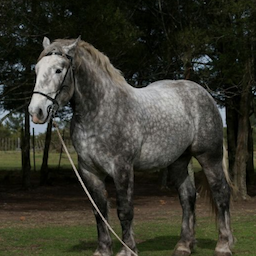

-------------------------------------------------------
Formato original da imagem (Estrutura física): (256, 256, 3)
Tipo de dado original da imagem na memória: uint8
-------------------------------------------------------
Formato final (Estrutura física): (670, 4096)
Tipo do dado final na memória: float32
Visualização - Característica 1 - CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:


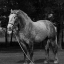

-------------------------------------------------------
EX COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 CAVALO:
Visualização dos 10 primeiros pixels no vetor:
 [31. 33. 29. 35. 27. 25. 18. 20.  9. 12.]
-------------------------------------------------------
--- TESTE DE DIAGNÓSTICO: Iniciando processamento da classe NÃO CAVALO ---
FLUXO DE EXECUÇÃO - Classe NÃO CAVALO: Raio x do pré-processamento


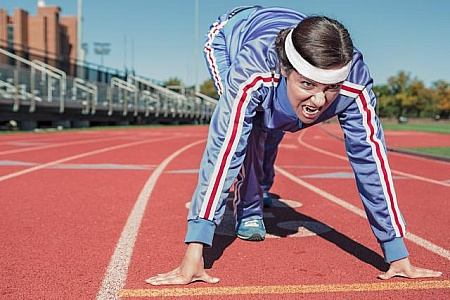

-------------------------------------------------------
MÉTRICAS INICIAIS DA IMAGEM DE ENTRADA
Formato original da imagem (Estrutura física): (300, 450, 3)
Tipo de dado original da imagem na memória: uint8
-------------------------------------------------------
Formato final (Estrutura física): (670, 4096)
Tipo do dado final na memória: float32
Visualização - Característica 1 - NÃO CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:


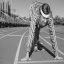

-------------------------------------------------------
COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 NÃO CAVALO :
Visualização dos 10 primeiros pixels no vetor:
 [158. 159. 159. 159. 158. 191. 174. 160. 159. 159.]
-------------------------------------------------------


In [2]:
import numpy as np
import cv2 as cv
import os
from google.colab.patches import cv2_imshow

# MANTER ESTAS VARIÁVEIS ATUALIZADAS PARA O LOCAL:
diretorio_destinoDrive_cavalos = "/content/cavalos"
diretorio_destinoDrive_nao_cavalos = "/content/nao_cavalos"

# Listar arquivos que estão dentro da pasta
arquivos_cavalos = os.listdir(diretorio_destinoDrive_cavalos)
arquivos_nao_cavalos = os.listdir(diretorio_destinoDrive_nao_cavalos)

# Listas para armazenar os resultados
resultadoVetores_cavalos = []
resultadoVetores_nao_cavalos = []

# Lista para guardar todas as imagems apos o pré-processamento, extração de caracteristica 1
imagensCom_Caracteristica1_cavalos = []
imagensCom_Caracteristica1_nao_cavalos = []

# EXTRAÇÃO CARACTERISTICAS DATASET CAVALOS
for nome_arquivo in arquivos_cavalos:
    # Cria o caminho completo para cada imagem (ex: /.../datasetCavalos/1.jpg)
    caminhoCompleto = os.path.join(diretorio_destinoDrive_cavalos, nome_arquivo)
    # Carrega a imagem atual
    img_original_cavalo = cv.imread(caminhoCompleto)

    # --- LOG DE SEGURANÇA ---
    if img_original_cavalo is None:
        print(f"AVISO: Pulando arquivo corrompido em CAVALOS: {nome_arquivo}")
        continue

    # converter imgs para tons de cinza
    caracteristica_1_cavalo = cv.cvtColor(img_original_cavalo, cv.COLOR_BGR2GRAY)

    # REPRESENTAÇÃO DA MESMA IMAGEM - PRIMEIRA: IMGREDIMENCIONADA - 64,64
    # REPRESENTACAO DA MESMA IMAGEM  - SEGUNDA: VETORCARACTERISTICAS - 4096 MESMA INFO MAS ACHATADA

    # redimensionar imgs
    tamanhoPadrao = (64, 64)
    imgRedimensionada_cavalos = cv.resize(caracteristica_1_cavalo, tamanhoPadrao, interpolation=cv.INTER_AREA)

    # Apenas para ver o logs:
    # Passo A: Achatar a matriz transformando em vetor unidimensional
    imagemAchatada_cavalo = imgRedimensionada_cavalos.flatten()
    # Passo B: Mudar o tipo do dado na memória para o padrão do k-NN
    vetorCaracteristicas = imagemAchatada_cavalo.astype(np.float32)
    resultadoVetores_cavalos.append(vetorCaracteristicas)

    # armazenando todas as imagens com caracteristica 1 já extraida
    imagensCom_Caracteristica1_cavalos.append(imgRedimensionada_cavalos)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_cavalos_np = np.array(resultadoVetores_cavalos)

print("FLUXO DE EXECUÇÃO - Classe CAVALO: Raio x do pré-processamento")
cv2_imshow(img_original_cavalo)
print("-" * 55)

print("Formato original da imagem (Estrutura física):", img_original_cavalo.shape)
print("Tipo de dado original da imagem na memória:", img_original_cavalo.dtype)
print("-" * 55)

print("Formato final (Estrutura física):", resultadoVetores_cavalos_np.shape)
print("Tipo do dado final na memória:", resultadoVetores_cavalos_np.dtype)

print("Visualização - Característica 1 - CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:")
cv2_imshow(imgRedimensionada_cavalos)
print("-" * 55)

print("EX COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 CAVALO:")
print("Visualização dos 10 primeiros pixels no vetor:")
print("", vetorCaracteristicas[:10])
print("-" * 55)

#EXTRAÇÃO CARACTERISTICAS DATASET NÃO CAVALOS
print("--- TESTE DE DIAGNÓSTICO: Iniciando processamento da classe NÃO CAVALO ---")
voltas = 0
for nome_arquivo in arquivos_nao_cavalos:
    voltas += 1

    # Cria o caminho completo para cada imagem
    caminhoCompleto = os.path.join(diretorio_destinoDrive_nao_cavalos, nome_arquivo)

    # Carrega a imagem atual
    img_original_nao_cavalos = cv.imread(caminhoCompleto)

    # --- LOG DE SEGURANÇA ---
    if img_original_nao_cavalos is None:
        print(f"AVISO: Pulando arquivo corrompido em NÃO CAVALOS (volta {voltas}): {nome_arquivo}")
        continue

    # converter imgs para tons de cinza
    caracteristica_1_nao_cavalos = cv.cvtColor(img_original_nao_cavalos, cv.COLOR_BGR2GRAY)
    # redimensionar imgs
    tamanhoPadrao = (64, 64)
    imgRedimensionada_nao_cavalos = cv.resize(caracteristica_1_nao_cavalos, tamanhoPadrao, interpolation=cv.INTER_AREA)

    # Passo A: Achatar a matriz transformando em vetor unidimensional
    imagemAchatada_nao_cavalos = imgRedimensionada_nao_cavalos.flatten()
    # Passo B: Mudar o tipo do dado na memória para o padrão do k-NN
    vetorCaracteristicas = imagemAchatada_nao_cavalos.astype(np.float32)

    resultadoVetores_nao_cavalos.append(vetorCaracteristicas)
    imagensCom_Caracteristica1_nao_cavalos.append(imgRedimensionada_nao_cavalos)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_nao_cavalos_np = np.array(resultadoVetores_nao_cavalos)

print("FLUXO DE EXECUÇÃO - Classe NÃO CAVALO: Raio x do pré-processamento")
cv2_imshow(img_original_nao_cavalos)
print("-" * 55)

print("MÉTRICAS INICIAIS DA IMAGEM DE ENTRADA")
print("Formato original da imagem (Estrutura física):", img_original_nao_cavalos.shape)
print("Tipo de dado original da imagem na memória:", img_original_nao_cavalos.dtype)
print("-" * 55)

print("Formato final (Estrutura física):", resultadoVetores_nao_cavalos_np.shape)
print("Tipo do dado final na memória:", resultadoVetores_nao_cavalos_np.dtype)
print("Visualização - Característica 1 - NÃO CAVALO, CONVERSÃO DE TONS E REDIMENSIONAMENTO:")
cv2_imshow(imgRedimensionada_nao_cavalos)
print("-" * 55)

print("COMO UMA IMAGEM VIRA VETOR, FOCANDO APENAS NA CARACTÉRISTICA 1 NÃO CAVALO :")
print("Visualização dos 10 primeiros pixels no vetor:")
print("", vetorCaracteristicas[:10])
print("-" * 55)

# Extração de Características:
### 2) Bordas e Gradientes

Esta célula executa a extração de características através da aplicação de filtros matemáticos independentes sobre a matriz de $64 \times 64$ em tons de cinza. A partir de uma única imagem de entrada, o fluxo gera **3 matrizes de características totalmente distintas** para os algoritmos de classificação:

1. **Sobel X:** Destaca as **bordas verticais** (percorre o eixo X e captura linhas verticais, como as pernas do animal).
2. **Sobel Y:** Destaca as **bordas horizontais** (percorre o eixo Y e captura linhas horizontais, como o dorso).
3. **Laplaciano:** Mapeia o **relevo geral**, capturando todas as direções de contorno simultaneamente.

**Nota Matemática de Implementação:** As transições de cor geram valores positivos e negativos na memória. Por isso, o código utiliza a profundidade `cv.CV_64F` para preservar os gradientes negativos, aplica o valor absoluto com `np.absolute()` e converte o tipo final para `float32`, formato padrão exigido para o cálculo de distância dos classificadores.

* **Hiperparâmetros configuráveis de teste:** Tamanho do Kernel (`ksize`), Direção da Derivada (`xorder`/`yorder`) e a variação estável do Filtro de Scharr.

Visualização - Característica 2 - CAVALO: Sobel X (Bordas Verticais)


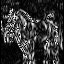

-------------------------------------------------------
Visualização - Característica 3 - CAVALO: Sobel Y (Bordas Horizontais)


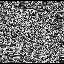

-------------------------------------------------------
Visualização - Característica 4 - CAVALO: Laplacian X (Todas as bordas)


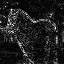

-------------------------------------------------------
Visualização - Característica 2 - NÃO CAVALO: Sobel X (Bordas Verticais)


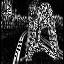

-------------------------------------------------------
Visualização - Característica 3 - NÃO CAVALO: Sobel Y (Bordas Horizontais)


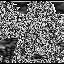

-------------------------------------------------------
Visualização - Característica 4 - NÃO CAVALO: Laplacian X (Todas as bordas)


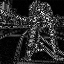

-------------------------------------------------------


In [3]:
# EXTRAÇÃO CARACTERISTICAS DATASET CAVALOS
resultadoVetores_caracteristica2_cavalos = []
resultadoVetores_caracteristica3_cavalos = []
resultadoVetores_caracteristica4_cavalos = []

for imgRedimensionada_cavalos in imagensCom_Caracteristica1_cavalos:
    # Função SOBEL x Gradiente Horizontal (mátematicamente calcula a derivada parcial horizontal)
    sobel_x_float = cv.Sobel(imgRedimensionada_cavalos, cv.CV_64F, 1, 0, ksize=3)
    # tranforma negativos em positivos
    sobel_x_absoluto_cavalo = np.absolute(sobel_x_float)
    # tipo para o uso do knn
    caracteristica_2_cavalo = sobel_x_absoluto_cavalo.astype(np.float32)
    resultadoVetores_caracteristica2_cavalos.append(caracteristica_2_cavalo.flatten())

    # Função SOBEL x Gradiente Vertical (mátematicamente calcula a derivada parcial vertical)
    sobel_y_float_cavalo = cv.Sobel(imgRedimensionada_cavalos, cv.CV_64F, 0, 1, ksize=5)
    sobel_y_absoluto_cavalo = np.absolute(sobel_y_float_cavalo)
    caracteristica_3_cavalo = sobel_y_absoluto_cavalo.astype(np.float32)
    resultadoVetores_caracteristica3_cavalos.append(caracteristica_3_cavalo.flatten())

    # Função LAPLACIANO x Gradiente de Segunda Ordem (calcula a soma das segundas derivadas especiais)
    laplacian_float_cavalo = cv.Laplacian(imgRedimensionada_cavalos, cv.CV_64F)
    # tranforma negativos em positivos
    laplacian_absoluto_cavalo = np.absolute(laplacian_float_cavalo)
    # tipo para o uso do knn
    caracteristica_4_cavalo = laplacian_absoluto_cavalo.astype(np.float32)
    resultadoVetores_caracteristica4_cavalos.append(caracteristica_4_cavalo.flatten())

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica2_cavalos_np = np.array(resultadoVetores_caracteristica2_cavalos)
resultadoVetores_caracteristica3_cavalos_np = np.array(resultadoVetores_caracteristica3_cavalos)
resultadoVetores_caracteristica4_cavalos_np = np.array(resultadoVetores_caracteristica4_cavalos)

# Conversão necessária apenas para a TELA conseguir MOSTRAR IMAGENS NOS LOGS
imagem_visual_x_cavalo = np.uint8(sobel_x_absoluto_cavalo)
imagem_visual_y_cavalo = np.uint8(sobel_y_absoluto_cavalo)
imagem_visual_lap_cavalo = np.uint8(laplacian_absoluto_cavalo)

print("Visualização - Característica 2 - CAVALO: Sobel X (Bordas Verticais)")
cv2_imshow(imagem_visual_x_cavalo)
print("-" * 55)
print("Visualização - Característica 3 - CAVALO: Sobel Y (Bordas Horizontais)")
cv2_imshow(imagem_visual_y_cavalo)
print("-" * 55)
print("Visualização - Característica 4 - CAVALO: Laplacian X (Todas as bordas)")
cv2_imshow(imagem_visual_lap_cavalo)
print("-" * 55)

# EXTRAÇÃO CARACTERISTICAS DATASET NÃO CAVALOS
resultadoVetores_caracteristica2_nao_cavalos = []
resultadoVetores_caracteristica3_nao_cavalos = []
resultadoVetores_caracteristica4_nao_cavalos = []

for imgRedimensionada_nao_cavalos in imagensCom_Caracteristica1_nao_cavalos:
    # Função SOBEL x Gradiente Horizontal (mátematicamente calcula a derivada parcial horizontal)
    sobel_x_float_nao_cavalos = cv.Sobel(imgRedimensionada_nao_cavalos, cv.CV_64F, 1, 0, ksize=3)
    # tranforma negativos em positivos
    sobel_x_absoluto_nao_cavalos = np.absolute(sobel_x_float_nao_cavalos)
    # tipo para o uso do knn
    caracteristica_2_nao_cavalos = sobel_x_absoluto_nao_cavalos.astype(np.float32)
    # conversao numPy
    resultadoVetores_caracteristica2_nao_cavalos.append(caracteristica_2_nao_cavalos.flatten())

    # Função SOBEL x Gradiente Vertical (mátematicamente calcula a derivada parcial vertical)
    sobel_y_float_nao_cavalos = cv.Sobel(imgRedimensionada_nao_cavalos, cv.CV_64F, 0, 1, ksize=5)
    sobel_y_absoluto_nao_cavalos = np.absolute(sobel_y_float_nao_cavalos)
    caracteristica_3_nao_cavalos = sobel_y_absoluto_nao_cavalos.astype(np.float32)
    resultadoVetores_caracteristica3_nao_cavalos.append(caracteristica_3_nao_cavalos.flatten())

    # Função LAPLACIANO x Gradiente de Segunda Ordem (calcula a soma das segundas derivadas especiais)
    laplacian_float_nao_cavalos = cv.Laplacian(imgRedimensionada_nao_cavalos, cv.CV_64F)
    # tranforma negativos em positivos
    laplacian_absoluto_nao_cavalos = np.absolute(laplacian_float_nao_cavalos)
    # tipo para o uso do knn
    caracteristica_4_nao_cavalos = laplacian_absoluto_nao_cavalos.astype(np.float32)
    resultadoVetores_caracteristica4_nao_cavalos.append(caracteristica_4_nao_cavalos.flatten())

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica2_nao_cavalos_np = np.array(resultadoVetores_caracteristica2_nao_cavalos)
resultadoVetores_caracteristica3_nao_cavalos_np = np.array(resultadoVetores_caracteristica3_nao_cavalos)
resultadoVetores_caracteristica4_nao_cavalos_np = np.array(resultadoVetores_caracteristica4_nao_cavalos)

# Conversão necessária apenas para a TELA conseguir MOSTRAR IMAGENS NOS LOGS
imagem_visual_x_nao_cavalos = np.uint8(sobel_x_absoluto_nao_cavalos)
imagem_visual_y_nao_cavalos = np.uint8(sobel_y_absoluto_nao_cavalos)
imagem_visual_lap_nao_cavalos = np.uint8(laplacian_absoluto_nao_cavalos)

print("Visualização - Característica 2 - NÃO CAVALO: Sobel X (Bordas Verticais)")
cv2_imshow(imagem_visual_x_nao_cavalos)
print("-" * 55)
print("Visualização - Característica 3 - NÃO CAVALO: Sobel Y (Bordas Horizontais)")
cv2_imshow(imagem_visual_y_nao_cavalos)
print("-" * 55)
print("Visualização - Característica 4 - NÃO CAVALO: Laplacian X (Todas as bordas)")
cv2_imshow(imagem_visual_lap_nao_cavalos)
print("-" * 55)

# Extração de Características:
### 3) Filtros de Textura, Frequência e Silhueta (Suavização e Geometria)

Esta célula executa a extração de características através da aplicação de filtros que simplificam a imagem e destacam o formato do animal. A partir da mesma imagem base ($64 \times 64$ pixels em tons de cinza), o fluxo gera mais **3 matrizes de características distintas** para os algoritmos de classificação:

1. **Desfoque Gaussiano:** Suaviza a imagem de forma homogênea. O filtro elimina detalhes irrelevantes de alta frequência (como texturas de pelos) e direciona o foco do classificador para o **tamanho, volume e postura macro** do corpo do cavalo.
2. **Filtro de Mediana:** Reduz ruídos isolados ao substituir o valor do pixel central pelo elemento mediano da vizinhança. O processo transforma superfícies texturizadas em blocos sólidos de intensidade, **sem borrar ou degradar o recorte das bordas**.
3. **Detector de Canny:** Converte a imagem em uma matriz binária (preto e branco puro). O algoritmo extingue todas as sombras e tons intermediários de cinza, isolando a **silhueta geométrica exata** do objeto.

**Nota Prática de Implementação:** O Gaussiano e a Mediana operam no rearranjo e ponderação dos pixels vizinhos para atenuar variações abruptas de textura. O Canny aplica um pipeline de limiarização por histerese para reter apenas as linhas de contorno principais. Ao final do processamento, ocorre a conversão de todas as matrizes para o tipo `float32`, formato padrão necessário para o cálculo de distância dos classificadores.

* **Hiperparâmetros configuráveis de teste:** Tamanho da matriz de varredura (`Kernel`), desvio padrão do borrão (`SigmaX`) e os limites de corte de linhas do Canny (`Limiares de Histerese`).

Visualização - Característica 5 - CAVALO: Desfoque Gaussiano (Suavização Natural)


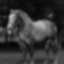

-------------------------------------------------------
Visualização - Característica 6 - CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)


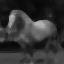

-------------------------------------------------------
Visualização - Característica 7 - CAVALO: Filtro Canny ( Detecção de Bordas de Canny)


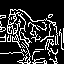

-------------------------------------------------------
Visualização - Característica 5 - NÃO CAVALO: Desfoque Gaussiano (Suavização Natural)


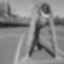

-------------------------------------------------------
Visualização - Característica 6 - NÃO CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)


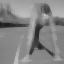

-------------------------------------------------------
Visualização - Característica 7 - NÃO CAVALO: Filtro Canny ( Detecção de Bordas de Canny)


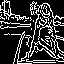

-------------------------------------------------------


In [4]:
#EXTRAÇÃO CARACTERISTICAS DATASET CAVALOS

# Listas para armazenar os resultados
resultadoVetores_caracteristica5_cavalos = []
resultadoVetores_caracteristica6_cavalos = []
resultadoVetores_caracteristica7_cavalos = []

for imgRedimensionada_cavalos in imagensCom_Caracteristica1_cavalos:

    # Desfoque Gaussiano
    gaussian_float_cavalo = cv.GaussianBlur(imgRedimensionada_cavalos, (5, 5), 0)
    # tranforma negativos em positivos
    caracteristica_5_cavalo = gaussian_float_cavalo.astype(np.float32)
    # transformar imagem em vetor para o k-NN
    vetorCaracteristica5 = caracteristica_5_cavalo.flatten()
    resultadoVetores_caracteristica5_cavalos.append(vetorCaracteristica5)

    # Filtro de Mediana
    median_float_cavalo = cv.medianBlur(imgRedimensionada_cavalos, 5)
    caracteristica_6_cavalo = median_float_cavalo.astype(np.float32)
    vetorCaracteristica6 = caracteristica_6_cavalo.flatten()
    resultadoVetores_caracteristica6_cavalos.append(vetorCaracteristica6)

    # Canny
    canny_float_cavalo = cv.Canny(imgRedimensionada_cavalos, 100, 200)
    caracteristica_7_cavalo = canny_float_cavalo.astype(np.float32)
    vetorCaracteristica7 = caracteristica_7_cavalo.flatten()
    resultadoVetores_caracteristica7_cavalos.append(vetorCaracteristica7)


# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica5_cavalos_np = np.array(resultadoVetores_caracteristica5_cavalos)
resultadoVetores_caracteristica6_cavalos_np = np.array(resultadoVetores_caracteristica6_cavalos)
resultadoVetores_caracteristica7_cavalos_np = np.array(resultadoVetores_caracteristica7_cavalos)

print("Visualização - Característica 5 - CAVALO: Desfoque Gaussiano (Suavização Natural)")
imagem_visual_gauss_cavalo = np.uint8(caracteristica_5_cavalo)
cv2_imshow(imagem_visual_gauss_cavalo)
print("-" * 55)

print("Visualização - Característica 6 - CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)")
imagem_visual_median_cavalo = np.uint8(caracteristica_6_cavalo)
cv2_imshow(imagem_visual_median_cavalo)
print("-" * 55)

print("Visualização - Característica 7 - CAVALO: Filtro Canny ( Detecção de Bordas de Canny)")
imagem_visual_canny_cavalo = np.uint8(caracteristica_7_cavalo)
cv2_imshow(imagem_visual_canny_cavalo)
print("-" * 55)


#EXTRAÇÃO CARACTERISTICAS DATASET NÃO CAVALOS
# Listas para armazenar os resultados
resultadoVetores_caracteristica5_nao_cavalos = []
resultadoVetores_caracteristica6_nao_cavalos = []
resultadoVetores_caracteristica7_nao_cavalos = []

for imgRedimensionada_nao_cavalos in imagensCom_Caracteristica1_nao_cavalos:

    # Desfoque  Gaussiano
    gaussian_float_nao_cavalos = cv.GaussianBlur(imgRedimensionada_nao_cavalos, (5, 5), 0)
    caracteristica_5_nao_cavalos = gaussian_float_nao_cavalos.astype(np.float32)
    vetorCaracteristica5 = caracteristica_5_nao_cavalos.flatten()
    resultadoVetores_caracteristica5_nao_cavalos.append(vetorCaracteristica5)

    # Mediana gaussian_float
    median_float_nao_cavalos = cv.medianBlur(imgRedimensionada_nao_cavalos, 5)
    caracteristica_6_nao_cavalos = median_float_nao_cavalos.astype(np.float32)
    vetorCaracteristica6 = caracteristica_6_nao_cavalos.flatten()
    resultadoVetores_caracteristica6_nao_cavalos.append(vetorCaracteristica6)

    # Canny
    canny_float_nao_cavalos = cv.Canny(imgRedimensionada_nao_cavalos, 100, 200)
    caracteristica_7_nao_cavalos = canny_float_nao_cavalos.astype(np.float32)
    vetorCaracteristica7 = caracteristica_7_nao_cavalos.flatten()
    resultadoVetores_caracteristica7_nao_cavalos.append(vetorCaracteristica7)

# Converte nova lista em vetor NumPy array - vetor de caracteristicas
resultadoVetores_caracteristica5_nao_cavalos_np = np.array(resultadoVetores_caracteristica5_nao_cavalos)
resultadoVetores_caracteristica6_nao_cavalos_np = np.array(resultadoVetores_caracteristica6_nao_cavalos)
resultadoVetores_caracteristica7_nao_cavalos_np = np.array(resultadoVetores_caracteristica7_nao_cavalos)

print("Visualização - Característica 5 - NÃO CAVALO: Desfoque Gaussiano (Suavização Natural)")
imagem_visual_gauss_nao_cavalos = np.uint8(caracteristica_5_nao_cavalos)
cv2_imshow(imagem_visual_gauss_nao_cavalos)
print("-" * 55)

print("Visualização - Característica 6 - NÃO CAVALO: Filtro de Mediana (Redução de Ruído com Bordas Firmes)")
imagem_visual_median_nao_cavalos = np.uint8(caracteristica_6_nao_cavalos)
cv2_imshow(imagem_visual_median_nao_cavalos)
print("-" * 55)

print("Visualização - Característica 7 - NÃO CAVALO: Filtro Canny ( Detecção de Bordas de Canny)")
imagem_visual_canny_nao_cavalos = np.uint8(caracteristica_7_nao_cavalos)
cv2_imshow(imagem_visual_canny_nao_cavalos)
print("-" * 55)

# AGRUPAMENTO (MATRIZ DE FEATURES)
## `np.concatenate()`

### É a função central para a consolidação de matrizes multidimensionais (`ndarrays`) no ecossistema NumPy. Essencial para o processamento e análise de dados, ele permite unir uma sequência de matrizes de forma rápida e eficiente em termos de memória.

**Regras de Ouro para a Concatenação:**
* **Estrutura Rígida:** Todos os elementos da tupla devem ser obrigatoriamente `Arrays NumPy` estruturados.
* **Compatibilidade de Shapes:** Os arrays precisam ter formatos compatíveis. Eles devem possuir o mesmo tamanho em todas as dimensões, exceto na dimensão em que a concatenação será realizada.
* **Dimensionalidade:** A união só pode ocorrer ao longo das dimensões existentes da matriz.

**Estrutura da Chamada:**
A função recebe dois argumentos principais: uma tupla contendo os arrays e o eixo (`axis`) de referência.

- np.concatenate((array1, array2, ...), axis=0)
    - axis=0: Empilha verticalmente (aumenta o número de linhas - ex: mais imagens)
    - axis=1: Empilha horizontalmente (aumenta o número de colunas - ex: mais atributos)

In [5]:

X_cavalos = np.concatenate(
    (resultadoVetores_cavalos_np, resultadoVetores_caracteristica2_cavalos_np,
     resultadoVetores_caracteristica3_cavalos_np, resultadoVetores_caracteristica4_cavalos_np,
     resultadoVetores_caracteristica5_cavalos_np, resultadoVetores_caracteristica6_cavalos_np,
     resultadoVetores_caracteristica7_cavalos_np), axis=1
)

X_nao_cavalos = np.concatenate(
    (resultadoVetores_nao_cavalos_np, resultadoVetores_caracteristica2_nao_cavalos_np,
     resultadoVetores_caracteristica3_nao_cavalos_np, resultadoVetores_caracteristica4_nao_cavalos_np,
     resultadoVetores_caracteristica5_nao_cavalos_np, resultadoVetores_caracteristica6_nao_cavalos_np,
     resultadoVetores_caracteristica7_nao_cavalos_np), axis=1
)

# PRINT DE CONFERÊNCIA
print("RELATÓRIO DE AGRUPAMENTO (MATRIZ DE FEATURES)")
print(f"Classe CAVALO: {X_cavalos.shape[0]} imagens | {X_cavalos.shape[1]} atributos totais")
print(f"Classe NÃO CAVALO: {X_nao_cavalos.shape[0]} imagens | {X_nao_cavalos.shape[1]} atributos totais")
print("-" * 55)

RELATÓRIO DE AGRUPAMENTO (MATRIZ DE FEATURES)
Classe CAVALO: 670 imagens | 28672 atributos totais
Classe NÃO CAVALO: 670 imagens | 28672 atributos totais
-------------------------------------------------------


## Etapa de Preparação de Dados: Pilares Universais

Independentemente do algoritmo de aprendizado escolhido, a qualidade do modelo é diretamente proporcional à integridade dos dados de entrada. A preparação segue quatro pilares fundamentais:

### 1. Limpeza e Validação (Garantia de Integridade)
Antes de qualquer processamento, asseguramos que a matriz de *features* seja confiável:
* **Tratamento de Falhas:** Identificação e remoção de amostras corrompidas ou incompletas (valores `NaN`/vazios) que comprometeriam o cálculo matemático.
* **Eliminação de Duplicatas:** Remoção de arquivos redundantes que poderiam induzir o modelo ao *overfitting* por memorização de instâncias específicas.
* **Verificação de Escrita:** Uso de checagem de integridade (tamanho de bytes) durante a transferência e carregamento dos dados para garantir que a imagem lida pelo OpenCV esteja íntegra.

### 2. Embaralhamento (*Shuffling*)
Fundamental para quebrar a ordem sequencial dos dados.
* Como datasets frequentemente vêm organizados por classe (ex: todos os cavalos, depois todos os não-cavalos), o **embaralhamento prévio** é vital. Sem ele, a divisão entre treino e teste seria tendenciosa, levando a uma falha estatística onde o modelo não seria exposto a uma distribuição realista das classes.

### 3. Divisão do Dataset (Blindagem contra *Overfitting*)
A separação correta garante que o modelo seja avaliado por sua capacidade de generalização:
* **Treino:** Conjunto de dados utilizado para o ajuste de pesos/parâmetros do modelo.
* **Teste:** Dados "virgens" que o modelo nunca viu durante o aprendizado, servindo como auditoria final de desempenho.
* **Estratificação:** Garantia de que a proporção das classes (ex: 50% cavalos, 50% não-cavalos) seja mantida tanto no treino quanto no teste, evitando viés de amostragem.

### 4. Engenharia e Transformação de *Features*
O escalonamento é o estágio crítico para algoritmos sensíveis à magnitude (como o k-NN):
* **Normalização/Padronização:** Ajuste das variáveis para uma mesma escala numérica, evitando que características com valores elevados (ex: intensidades de pixel de 0 a 255) dominem indevidamente características com escalas menores.
* **Transformação de Dimensionalidade:** Conversão de matrizes espaciais em vetores unidimensionais (achatamento), permitindo que o modelo trate a imagem como um conjunto de atributos numéricos comparáveis.

In [6]:
# Limpeza e Validação
import numpy as np
# Verificar se existem valores nulos ou infinitos nas matrizes
def validar_dados(X, nome):
   if np.isnan(X).any() or np.isinf(X).any():
       print(f"ALERTA: Dados inválidos (NaN/Inf) encontrados em {nome}")
   else:
       print(f"OK: Dados em {nome} estão limpos e prontos.")
validar_dados(X_cavalos, "X_cavalos")
validar_dados(X_nao_cavalos, "X_nao_cavalos")

OK: Dados em X_cavalos estão limpos e prontos.
OK: Dados em X_nao_cavalos estão limpos e prontos.


In [7]:
# Embaralhamento e Divisão (Estratificada)
from sklearn.model_selection import train_test_split

# Criar rótulos e concatenar (X e y já prontos)
y_cavalos = np.ones(X_cavalos.shape[0])
y_nao_cavalos = np.zeros(X_nao_cavalos.shape[0])
X = np.concatenate((X_cavalos, X_nao_cavalos), axis=0)
y = np.concatenate((y_cavalos, y_nao_cavalos), axis=0)

# Divisão: 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Dados divididos: Treino={X_train.shape[0]}, Teste={X_test.shape[0]}")

Dados divididos: Treino=1072, Teste=268


In [8]:
# Escalonamento (Padronização)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# O scaler "aprende" a média e o desvio apenas com os dados de treino
X_train = scaler.fit_transform(X_train)# Aplicamos o mesmo aprendizado nos dados de teste
X_test = scaler.transform(X_test)
print("Dados escalonados com sucesso!")

Dados escalonados com sucesso!


In [9]:
# Verificação Final
print("Formato final para o modelo:")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Média de X_train (deve ser próximo de 0): {X_train.mean():.4f}")
print(f"Desvio de X_train (deve ser próximo de 1): {X_train.std():.4f}")
# Se a média for próxima de 0 e o desvio próximo de 1, o escalonamento funcionou perfeitamente.

Formato final para o modelo:
X_train: (1072, 28672)
X_test:  (268, 28672)
Média de X_train (deve ser próximo de 0): 0.0000
Desvio de X_train (deve ser próximo de 1): 0.9955


Com a preparação dos dados, quando o algoritmo k-NN for calcular a Distância Euclidiana entre as imagens, ele tratará todos os pixels e bordas de forma justa. Nenhuma característica vai "abafar" a outra apenas porque seus valores numéricos eram maiores.

# Treino - kNN

O que acontece no lugar das épocas no k-NN:Fase de Treino (Memorização): Quando você roda o .fit(), o algoritmo apenas indexa seus vetores de 28.672 características em uma estrutura de busca para facilitar o acesso futuro. Ele faz isso uma única vez. Não há repetição de ciclos (épocas).  Fase de Teste (Consulta): Quando você roda o .predict(), ele percorre o conjunto de teste e busca as similaridades. A "inteligência" do modelo acontece inteiramente nesta busca em tempo de execução.  

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

# Definição do Modelo
# 'n_neighbors=5' parâmetro define a quantidade de "vizinhos" que o algoritmo consultará para tomar uma decisão.
knn = KNeighborsClassifier(n_neighbors=5, metric='manhattan')

# Treino (O 'fit' mapeia os dados no espaço vetorial)
knn.fit(X_train, y_train)

# Predição
# O modelo calcula a distância dos novos pontos (X_test) aos vizinhos mais próximos
y_pred = knn.predict(X_test)

# Avaliação
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7201492537313433
              precision    recall  f1-score   support

         0.0       0.65      0.96      0.77       134
         1.0       0.93      0.48      0.63       134

    accuracy                           0.72       268
   macro avg       0.79      0.72      0.70       268
weighted avg       0.79      0.72      0.70       268



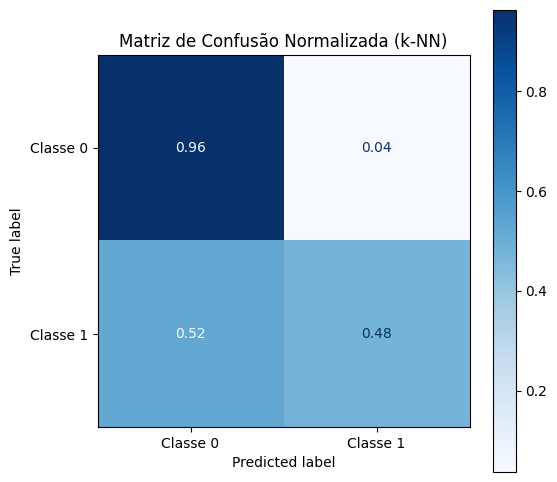

In [11]:
#Matriz Confusão
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Adicionamos o 'normalize' aqui.
# 'true' normaliza pelas linhas (mostra a taxa de acerto/erro por classe real)
cm = confusion_matrix(y_test, y_pred, normalize='true')

# Plotar a matriz
fig, ax = plt.subplots(figsize=(6, 6))
# 'values_format' define que queremos 2 casas decimais (ex: 0.88)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Classe 0', 'Classe 1'])
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='.2f')

plt.title("Matriz de Confusão Normalizada (k-NN)")
plt.show()

In [14]:
import os
import pickle
from google.colab import drive

# Monta o Drive
drive.mount('/content/drive')

# Caminho base
base_path = '/content/drive/MyDrive/Trabalho_SistemasInteligentes/versoes'

# Lógica para criar a próxima pasta (v1, v2, v3...)
# Lista todas as pastas no diretório base
subpastas = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
# Filtra apenas pastas que começam com 'v' e calcula a próxima
versoes = [int(d[1:]) for d in subpastas if d.startswith('v') and d[1:].isdigit()]
proxima_versao = max(versoes) + 1 if versoes else 1

# Define o caminho da nova pasta (ex: .../versoes/v2)
caminho_versao = os.path.join(base_path, f'v{proxima_versao}')
os.makedirs(caminho_versao, exist_ok=True)

# Salva os arquivos dentro da nova pasta
# Salva a Matriz de Confusão
disp.figure_.savefig(os.path.join(caminho_versao, 'matriz_confusao.png'))

# Salva o arquivo .pkl
versao_projeto = {
    'modelo': knn,
    'configuracoes_treino': {
        'n_vizinhos': knn.n_neighbors,
        'metrica': knn.metric,
        'pesos': knn.weights
    }
}

caminho_arquivo = os.path.join(caminho_versao, 'projeto_final.pkl')
with open(caminho_arquivo, 'wb') as arquivo:
    pickle.dump(versao_projeto, arquivo)

print(f"Arquivos salvos com sucesso na nova pasta: {caminho_versao}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Arquivos salvos com sucesso na nova pasta: /content/drive/MyDrive/Trabalho_SistemasInteligentes/versoes/v8


In [15]:
import pandas as pd
import os
from sklearn.metrics import classification_report, accuracy_score

# Define o caminho do arquivo de log
caminho_csv = '/content/drive/MyDrive/Trabalho_SistemasInteligentes/versoes/historico_metricas.csv'

# Extrai as métricas (usando classification_report como dicionário)
report = classification_report(y_test, y_pred, output_dict=True)

#  Cria um dicionário com os valores para esta versão
nova_linha = {
    'versao': 'Versao_8',
    'accuracy': report['accuracy'],
    'precision_0': report['0.0']['precision'],
    'recall_0': report['0.0']['recall'],
    'f1_0': report['0.0']['f1-score'],
    'precision_1': report['1.0']['precision'],
    'recall_1': report['1.0']['recall'],
    'f1_1': report['1.0']['f1-score']
}

# Transforma em DataFrame
df_novo = pd.DataFrame([nova_linha])

# Adiciona ao arquivo existente ou cria um novo
if os.path.exists(caminho_csv):
    df_historico = pd.read_csv(caminho_csv)
    df_final = pd.concat([df_historico, df_novo], ignore_index=True)
else:
    df_final = df_novo

# Salva no Drive
df_final.to_csv(caminho_csv, index=False)

print(f"Métricas da {nova_linha['versao']} adicionadas com sucesso ao arquivo: {caminho_csv}")

Métricas da Versao_8 adicionadas com sucesso ao arquivo: /content/drive/MyDrive/Trabalho_SistemasInteligentes/versoes/historico_metricas.csv
